In [42]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    ExtraTreesRegressor,
    HistGradientBoostingRegressor,
    AdaBoostRegressor
)

from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

import warnings
warnings.filterwarnings("ignore")

In [43]:
df = pd.read_csv(
    r"C:\Users\HP\Jupyter Note Book\DDMM\standard_scaled_dataset.csv"
)

print("Shape:", df.shape)

df.head()

Shape: (14992, 8)


,Discharge Time (s),Decrement 3.6-3.4V (s),Max. Voltage Dischar. (V),Min. Voltage Charg. (V),Time at 4.15V (s),Time constant current (s),Charging time (s),RUL
0,-0.052560,-0.021265,-2.647285,-2.999948,0.201022,0.057978,0.032341,1112
1,0.098135,-0.019743,3.761850,-2.926318,0.206570,0.058263,0.021627,1111
2,0.097669,-0.024052,3.795231,-2.893594,0.206570,0.058263,0.018539,1110
3,0.097410,-0.026418,3.806358,-2.885413,0.205780,0.058263,0.014771,1109
4,1.901905,2.053925,4.251437,-1.470097,0.203399,1.948155,1.805569,1107


In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14992 entries, 0 to 14991
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Discharge Time (s)         14992 non-null  float64
 1   Decrement 3.6-3.4V (s)     14992 non-null  float64
 2   Max. Voltage Dischar. (V)  14992 non-null  float64
 3   Min. Voltage Charg. (V)    14992 non-null  float64
 4   Time at 4.15V (s)          14992 non-null  float64
 5   Time constant current (s)  14992 non-null  float64
 6   Charging time (s)          14992 non-null  float64
 7   RUL                        14992 non-null  int64  
dtypes: float64(7), int64(1)
memory usage: 937.1 KB


In [45]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Discharge Time (s),14992.0,5.118638e-17,1.000000,-0.133541,-0.097130,-0.085051,-0.074078,29.869077
Decrement 3.6-3.4V (s),14992.0,4.170742e-17,1.000000,-0.102379,-0.081418,-0.072779,-0.061078,29.341588
Max. Voltage Dischar. (V),14992.0,-6.256113e-16,1.000000,-9.623896,-0.688939,-0.021320,0.713060,5.063706
Min. Voltage Charg. (V),14992.0,-3.002934e-15,1.000000,-4.546160,-0.733806,-0.038419,0.697872,5.909180
Time at 4.15V (s),14992.0,7.583167e-18,1.000000,-0.415757,-0.209263,-0.085472,0.045136,27.341484
Time constant current (s),14992.0,1.801002e-17,1.000000,-0.216608,-0.112520,-0.061258,-0.012923,35.615801
Charging time (s),14992.0,6.990732e-17,1.000000,-0.383604,-0.080860,-0.062503,-0.045488,33.624655
RUL,14992.0,5.549416e+02,322.175186,0.000000,279.000000,551.000000,840.000000,1133.000000


In [46]:
df.isnull().sum()

Discharge Time (s)           0
Decrement 3.6-3.4V (s)       0
Max. Voltage Dischar. (V)    0
Min. Voltage Charg. (V)      0
Time at 4.15V (s)            0
Time constant current (s)    0
Charging time (s)            0
RUL                          0
dtype: int64

In [47]:
df.duplicated().sum()

np.int64(0)

In [48]:
np.isinf(
    df.select_dtypes(include=np.number)
).sum()

Discharge Time (s)           0
Decrement 3.6-3.4V (s)       0
Max. Voltage Dischar. (V)    0
Min. Voltage Charg. (V)      0
Time at 4.15V (s)            0
Time constant current (s)    0
Charging time (s)            0
RUL                          0
dtype: int64

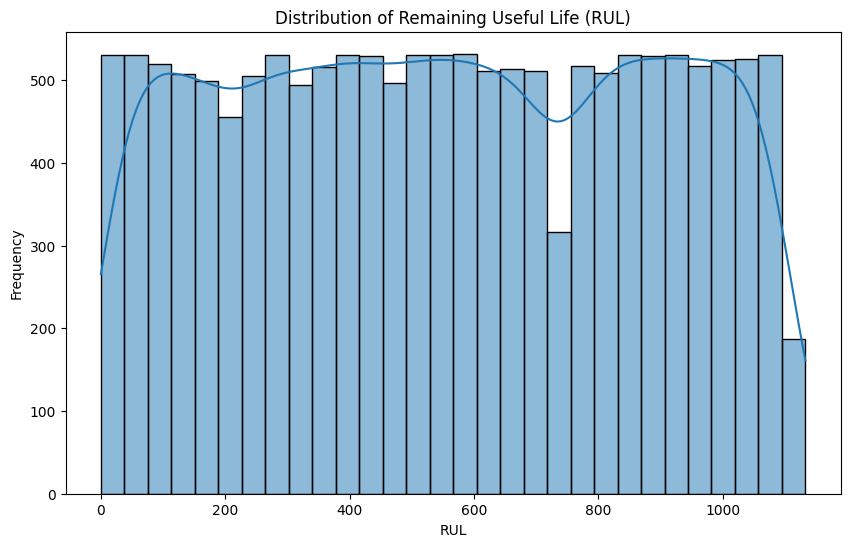

In [49]:
plt.figure(figsize=(10, 6))

sns.histplot(
    df["RUL"],
    bins=30,
    kde=True
)

plt.title("Distribution of Remaining Useful Life (RUL)")
plt.xlabel("RUL")
plt.ylabel("Frequency")

plt.show()

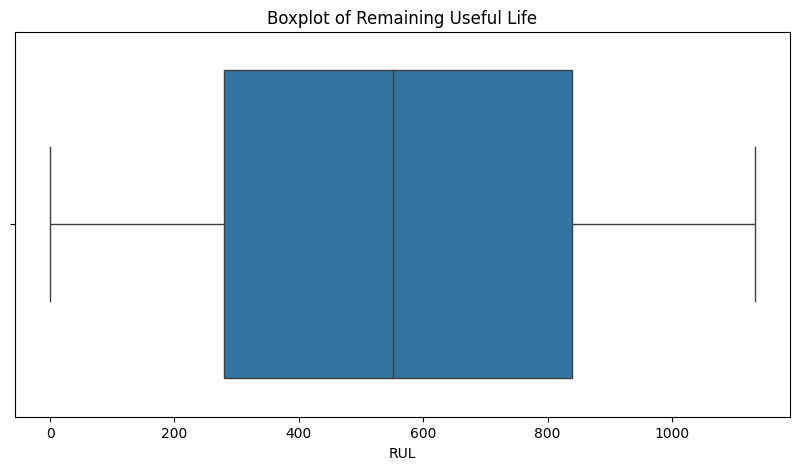

In [50]:
plt.figure(figsize=(10, 5))

sns.boxplot(
    x=df["RUL"]
)

plt.title("Boxplot of Remaining Useful Life")
plt.xlabel("RUL")

plt.show()

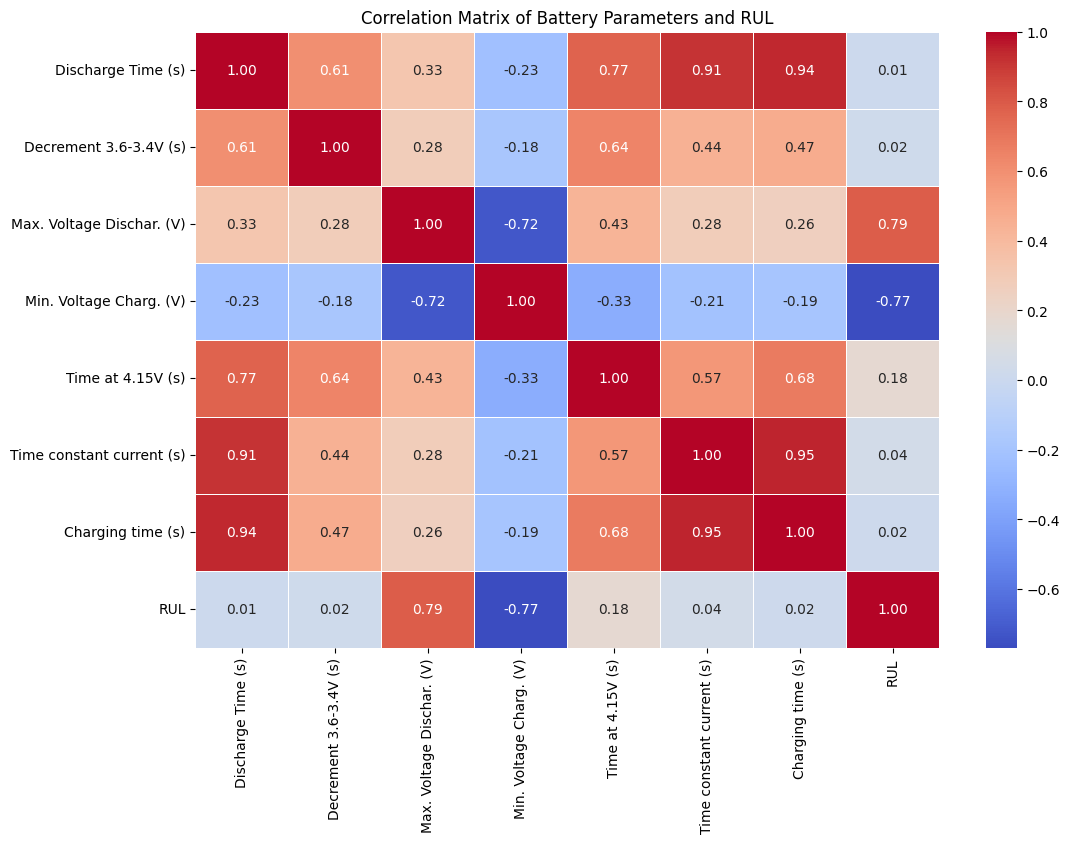

In [51]:
plt.figure(figsize=(12, 8))

correlation_matrix = df.corr(numeric_only=True)

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Matrix of Battery Parameters and RUL")

plt.show()

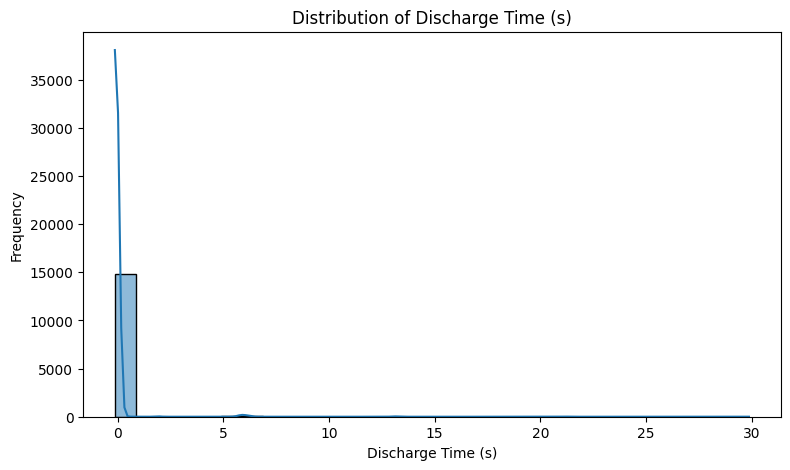

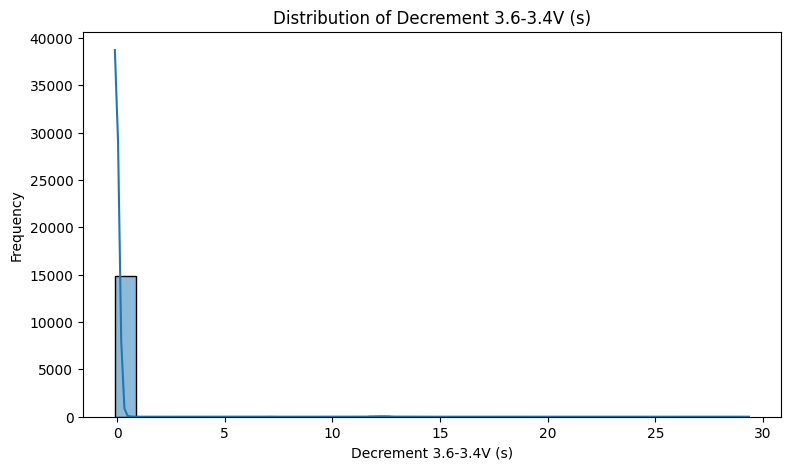

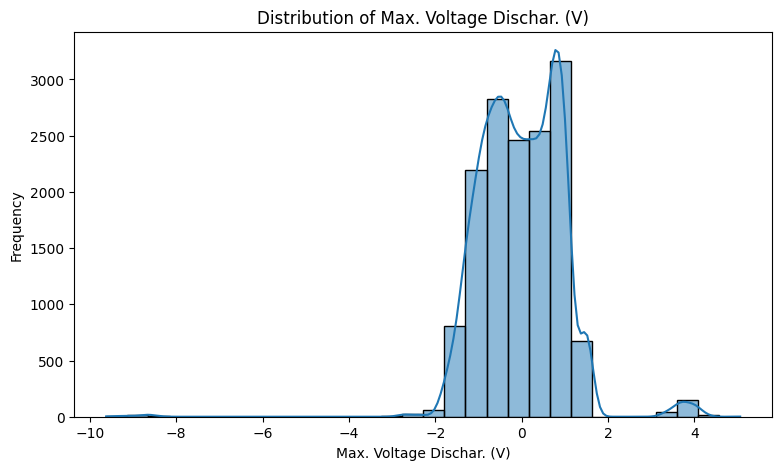

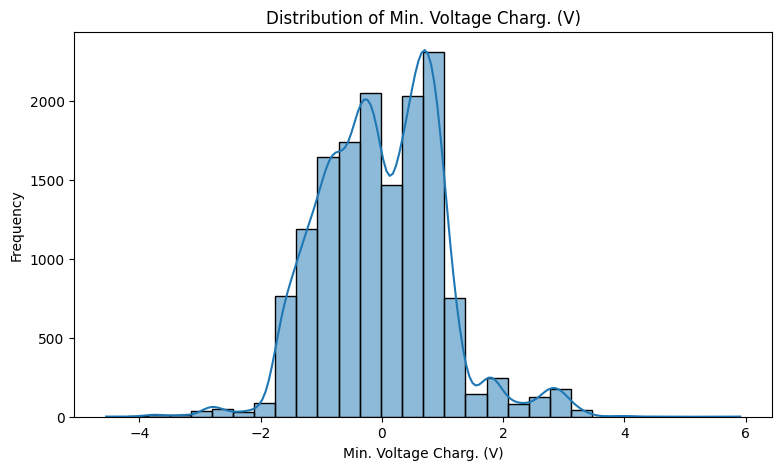

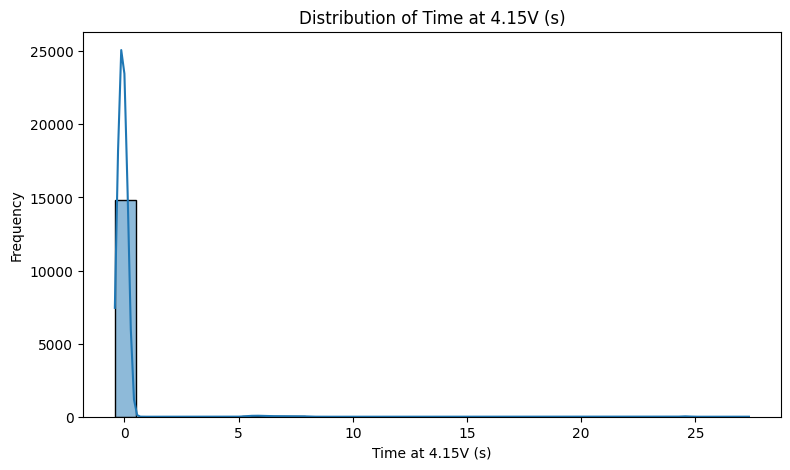

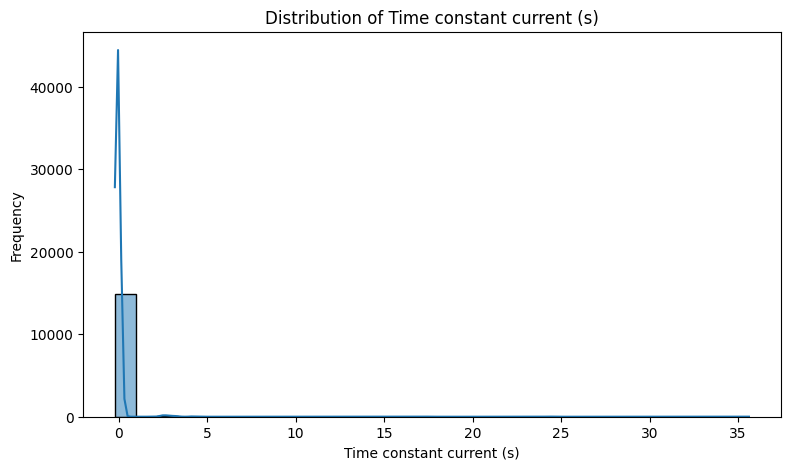

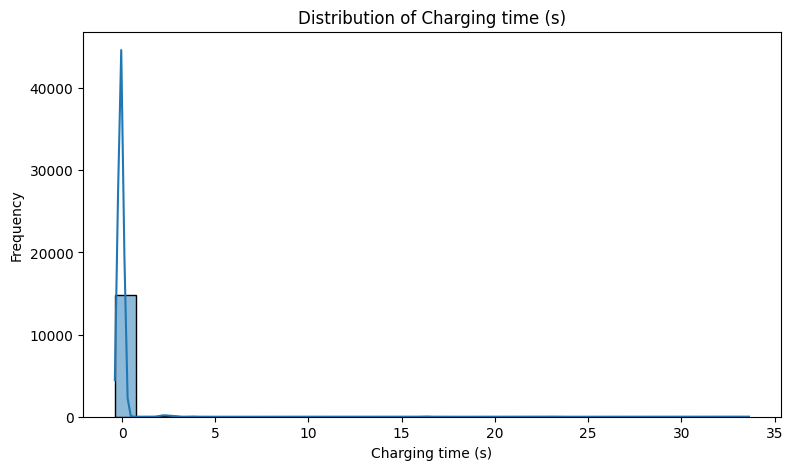

In [52]:
X = df.drop(columns=["RUL"])

y = df["RUL"]


features = X.columns

for feature in features:

    plt.figure(figsize=(9, 5))

    sns.histplot(
        X[feature],
        kde=True,
        bins=30
    )

    plt.title(f"Distribution of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Frequency")

    plt.show()

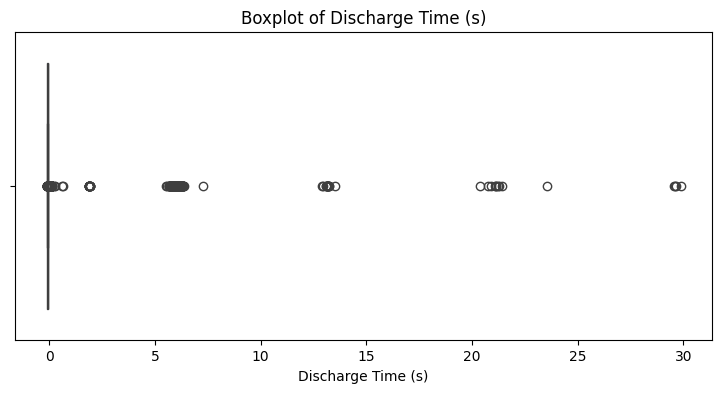

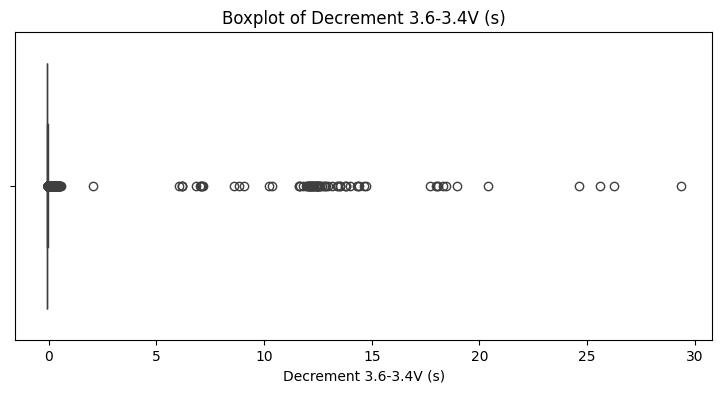

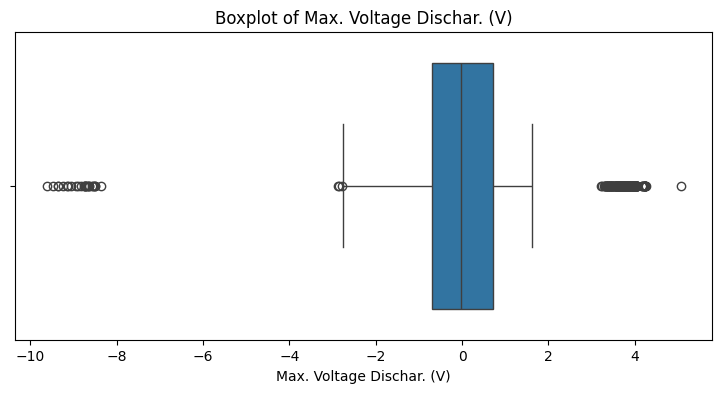

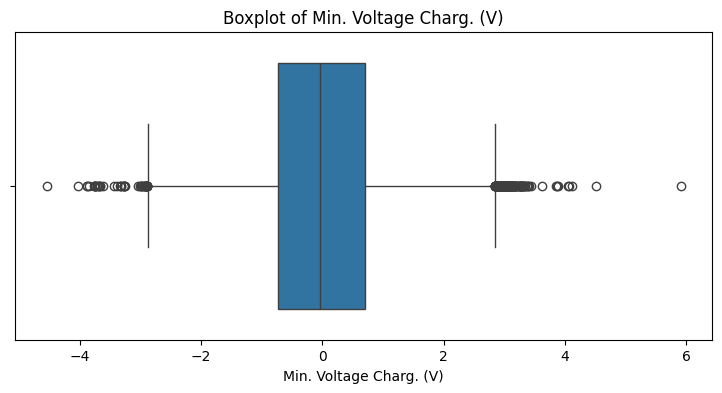

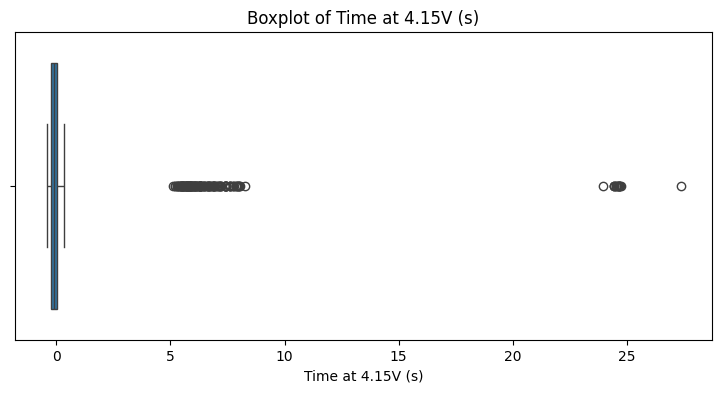

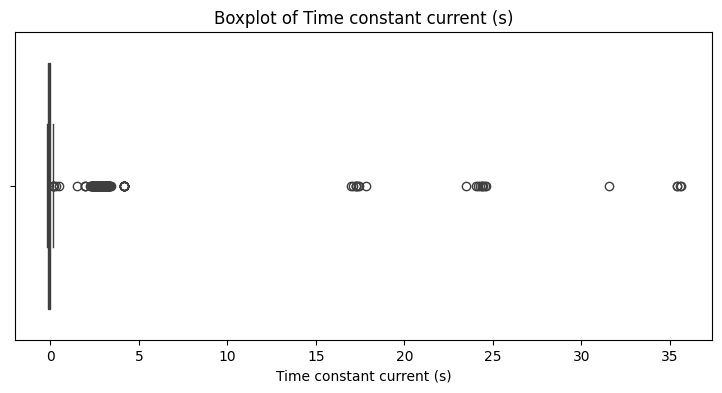

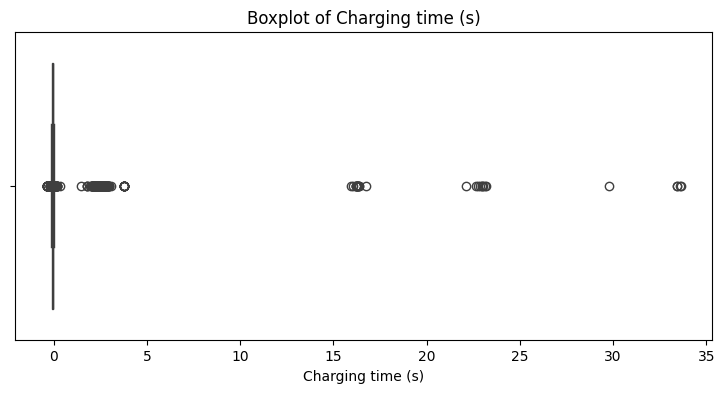

In [53]:
for feature in features:
    plt.figure(figsize=(9, 4))
    
    sns.boxplot(x=df[feature])
    
    plt.title(f"Boxplot of {feature}")
    plt.xlabel(feature)
    
    plt.show()

In [54]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [55]:
rf_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", RandomForestRegressor(
        random_state=42,
        n_jobs=-1
    ))
])

rf_pipeline.fit(X_train, y_train)

rf_train_pred = rf_pipeline.predict(X_train)
rf_test_pred = rf_pipeline.predict(X_test)

In [56]:
gb_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", GradientBoostingRegressor(
        random_state=42
    ))
])

gb_pipeline.fit(X_train, y_train)

gb_train_pred = gb_pipeline.predict(X_train)
gb_test_pred = gb_pipeline.predict(X_test)

In [57]:
xgb_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", XGBRegressor(
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    ))
])

xgb_pipeline.fit(X_train, y_train)

xgb_train_pred = xgb_pipeline.predict(X_train)
xgb_test_pred = xgb_pipeline.predict(X_test)

In [58]:
lgbm_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LGBMRegressor(
        random_state=42,
        verbosity=-1,
        n_jobs=-1
    ))
])

lgbm_pipeline.fit(X_train, y_train)

lgbm_train_pred = lgbm_pipeline.predict(X_train)
lgbm_test_pred = lgbm_pipeline.predict(X_test)

In [59]:
extra_trees_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", ExtraTreesRegressor(
        random_state=42,
        n_jobs=-1
    ))
])

extra_trees_pipeline.fit(X_train, y_train)

extra_trees_train_pred = extra_trees_pipeline.predict(X_train)
extra_trees_test_pred = extra_trees_pipeline.predict(X_test)

In [60]:
catboost_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", CatBoostRegressor(
        random_state=42,
        verbose=0,
        allow_writing_files=False
    ))
])

catboost_pipeline.fit(X_train, y_train)

catboost_train_pred = catboost_pipeline.predict(X_train)
catboost_test_pred = catboost_pipeline.predict(X_test)

In [61]:
hist_gb_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", HistGradientBoostingRegressor(
        random_state=42
    ))
])

hist_gb_pipeline.fit(X_train, y_train)

hist_gb_train_pred = hist_gb_pipeline.predict(X_train)
hist_gb_test_pred = hist_gb_pipeline.predict(X_test)

In [62]:
svr_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVR())
])

svr_pipeline.fit(X_train, y_train)

svr_train_pred = svr_pipeline.predict(X_train)
svr_test_pred = svr_pipeline.predict(X_test)

In [63]:
adaboost_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", AdaBoostRegressor(
        random_state=42
    ))
])

adaboost_pipeline.fit(X_train, y_train)

adaboost_train_pred = adaboost_pipeline.predict(X_train)
adaboost_test_pred = adaboost_pipeline.predict(X_test)

In [64]:
knn_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", KNeighborsRegressor(
        n_jobs=-1
    ))
])

knn_pipeline.fit(X_train, y_train)

knn_train_pred = knn_pipeline.predict(X_train)
knn_test_pred = knn_pipeline.predict(X_test)

In [65]:
models = {
    "Random Forest": rf_pipeline,
    "Gradient Boosting": gb_pipeline,
    "XGBoost": xgb_pipeline,
    "LightGBM": lgbm_pipeline,
    "Extra Trees": extra_trees_pipeline,
    "CatBoost": catboost_pipeline,
    "HistGradientBoosting": hist_gb_pipeline,
    "SVR": svr_pipeline,
    "AdaBoost": adaboost_pipeline,
    "KNN": knn_pipeline
}

print("Models available:")

for name in models:
    print("-", name)

Models available:
- Random Forest
- Gradient Boosting
- XGBoost
- LightGBM
- Extra Trees
- CatBoost
- HistGradientBoosting
- SVR
- AdaBoost
- KNN


In [66]:
train_predictions = {
    "Random Forest": rf_train_pred,
    "Gradient Boosting": gb_train_pred,
    "XGBoost": xgb_train_pred,
    "LightGBM": lgbm_train_pred,
    "Extra Trees": extra_trees_train_pred,
    "CatBoost": catboost_train_pred,
    "HistGradientBoosting": hist_gb_train_pred,
    "SVR": svr_train_pred,
    "AdaBoost": adaboost_train_pred,
    "KNN": knn_train_pred
}

In [67]:
test_predictions = {
    "Random Forest": rf_test_pred,
    "Gradient Boosting": gb_test_pred,
    "XGBoost": xgb_test_pred,
    "LightGBM": lgbm_test_pred,
    "Extra Trees": extra_trees_test_pred,
    "CatBoost": catboost_test_pred,
    "HistGradientBoosting": hist_gb_test_pred,
    "SVR": svr_test_pred,
    "AdaBoost": adaboost_test_pred,
    "KNN": knn_test_pred
}

In [68]:
baseline_results = []

for name in models:

    train_pred = train_predictions[name]
    test_pred = test_predictions[name]

    train_mae = mean_absolute_error(
        y_train,
        train_pred
    )

    test_mae = mean_absolute_error(
        y_test,
        test_pred
    )

    train_rmse = np.sqrt(
        mean_squared_error(
            y_train,
            train_pred
        )
    )

    test_rmse = np.sqrt(
        mean_squared_error(
            y_test,
            test_pred
        )
    )

    train_r2 = r2_score(
        y_train,
        train_pred
    )

    test_r2 = r2_score(
        y_test,
        test_pred
    )

    baseline_results.append([
        name,
        train_mae,
        test_mae,
        train_rmse,
        test_rmse,
        train_r2,
        test_r2
    ])

    print("\n" + "=" * 50)
    print(name)
    print("=" * 50)

    print("Train MAE  :", round(train_mae, 4))
    print("Test MAE   :", round(test_mae, 4))

    print("Train RMSE :", round(train_rmse, 4))
    print("Test RMSE  :", round(test_rmse, 4))

    print("Train R²   :", round(train_r2, 4))
    print("Test R²    :", round(test_r2, 4))


Random Forest
Train MAE  : 3.6338
Test MAE   : 9.5645
Train RMSE : 7.8475
Test RMSE  : 21.2407
Train R²   : 0.9994
Test R²    : 0.9956

Gradient Boosting
Train MAE  : 29.6409
Test MAE   : 30.4337
Train RMSE : 40.0378
Test RMSE  : 41.6187
Train R²   : 0.9846
Test R²    : 0.983

XGBoost
Train MAE  : 8.7014
Test MAE   : 13.5597
Train RMSE : 12.9327
Test RMSE  : 22.3535
Train R²   : 0.9984
Test R²    : 0.9951

LightGBM
Train MAE  : 17.0777
Test MAE   : 19.5137
Train RMSE : 24.7192
Test RMSE  : 31.341
Train R²   : 0.9941
Test R²    : 0.9904

Extra Trees
Train MAE  : 0.0062
Test MAE   : 7.8121
Train RMSE : 0.0951
Test RMSE  : 17.4971
Train R²   : 1.0
Test R²    : 0.997

CatBoost
Train MAE  : 14.077
Test MAE   : 16.8052
Train RMSE : 19.8907
Test RMSE  : 25.8003
Train R²   : 0.9962
Test R²    : 0.9935

HistGradientBoosting
Train MAE  : 17.858
Test MAE   : 19.8161
Train RMSE : 26.5873
Test RMSE  : 30.442
Train R²   : 0.9932
Test R²    : 0.9909

SVR
Train MAE  : 68.5133
Test MAE   : 67.5365
Tra

In [69]:
baseline_results_df = pd.DataFrame(
    baseline_results,
    columns=[
        "Model",
        "Train MAE",
        "Test MAE",
        "Train RMSE",
        "Test RMSE",
        "Train R²",
        "Test R²"
    ]
)

baseline_results_df

,Model,Train MAE,Test MAE,Train RMSE,Test RMSE,Train R²,Test R²
0,Random Forest,3.633786,9.564478,7.847546,21.240654,0.999409,0.995568
1,Gradient Boosting,29.640929,30.433715,40.037801,41.618656,0.984629,0.982985
2,XGBoost,8.701430,13.559671,12.932684,22.353508,0.998396,0.995092
3,LightGBM,17.077699,19.513659,24.719169,31.341030,0.994141,0.990351
4,Extra Trees,0.006207,7.812064,0.095136,17.497125,1.000000,0.996993
5,CatBoost,14.076954,16.805208,19.890698,25.800305,0.996206,0.993461
6,HistGradientBoosting,17.858033,19.816143,26.587339,30.441963,0.993222,0.990897
7,SVR,68.513317,67.536535,101.602923,101.708708,0.901012,0.898383
8,AdaBoost,54.112807,53.481859,66.284143,65.812600,0.957870,0.957453
9,KNN,11.160810,14.287029,27.677804,30.359252,0.992654,0.990946


In [70]:
final_results = baseline_results_df.sort_values(
    by="Test R²",
    ascending=False
).reset_index(drop=True)

final_results

,Model,Train MAE,Test MAE,Train RMSE,Test RMSE,Train R²,Test R²
0,Extra Trees,0.006207,7.812064,0.095136,17.497125,1.000000,0.996993
1,Random Forest,3.633786,9.564478,7.847546,21.240654,0.999409,0.995568
2,XGBoost,8.701430,13.559671,12.932684,22.353508,0.998396,0.995092
3,CatBoost,14.076954,16.805208,19.890698,25.800305,0.996206,0.993461
4,KNN,11.160810,14.287029,27.677804,30.359252,0.992654,0.990946
5,HistGradientBoosting,17.858033,19.816143,26.587339,30.441963,0.993222,0.990897
6,LightGBM,17.077699,19.513659,24.719169,31.341030,0.994141,0.990351
7,Gradient Boosting,29.640929,30.433715,40.037801,41.618656,0.984629,0.982985
8,AdaBoost,54.112807,53.481859,66.284143,65.812600,0.957870,0.957453
9,SVR,68.513317,67.536535,101.602923,101.708708,0.901012,0.898383


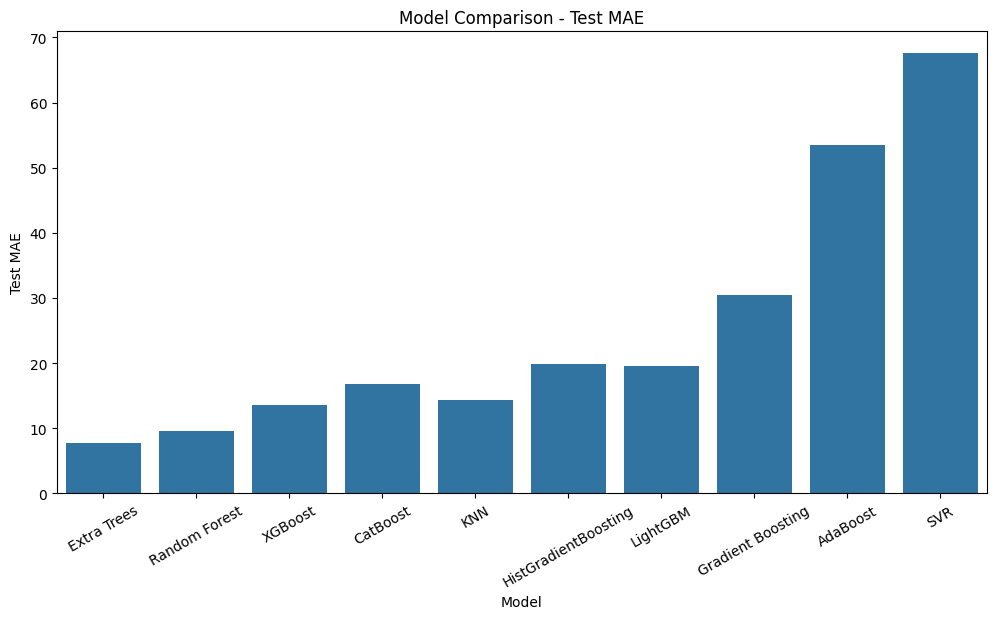

In [71]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=final_results,
    x="Model",
    y="Test MAE"
)

plt.title("Model Comparison - Test MAE")
plt.xlabel("Model")
plt.ylabel("Test MAE")
plt.xticks(rotation=30)

plt.show()

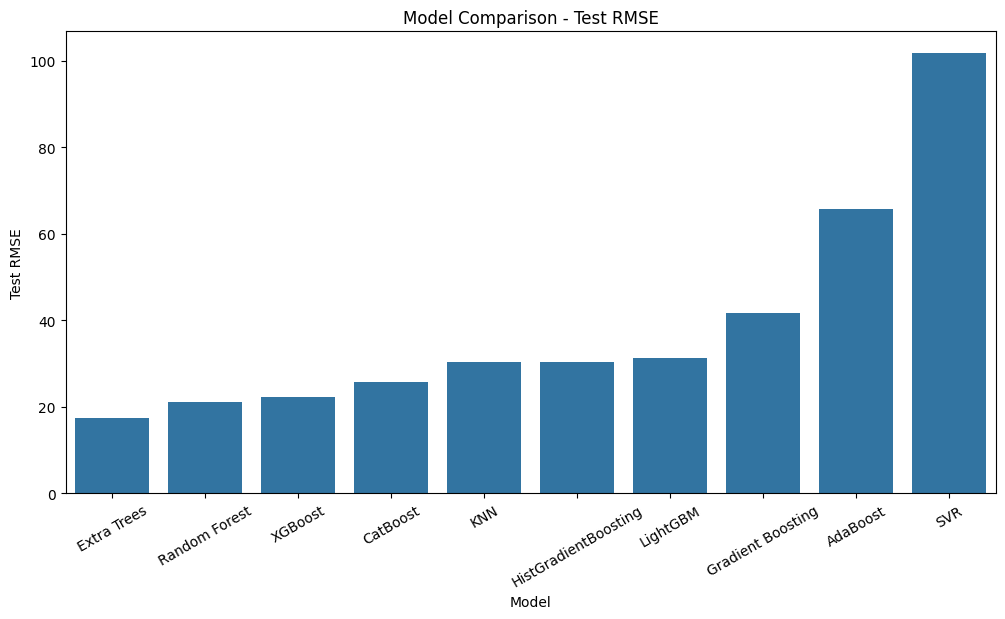

In [72]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=final_results,
    x="Model",
    y="Test RMSE"
)

plt.title("Model Comparison - Test RMSE")
plt.xlabel("Model")
plt.ylabel("Test RMSE")
plt.xticks(rotation=30)

plt.show()

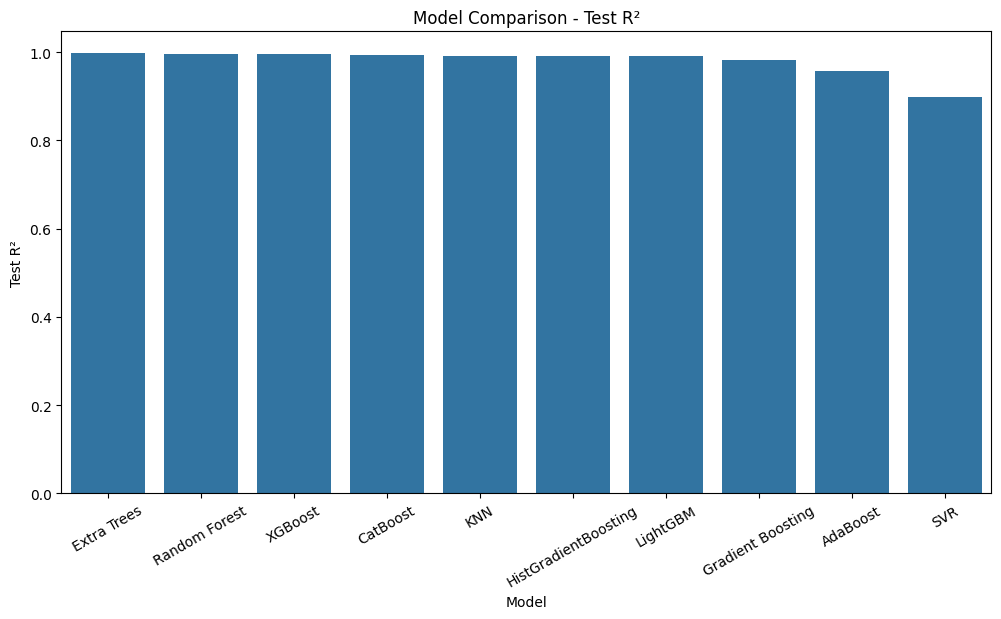

In [73]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=final_results,
    x="Model",
    y="Test R²"
)

plt.title("Model Comparison - Test R²")
plt.xlabel("Model")
plt.ylabel("Test R²")
plt.xticks(rotation=30)

plt.show()

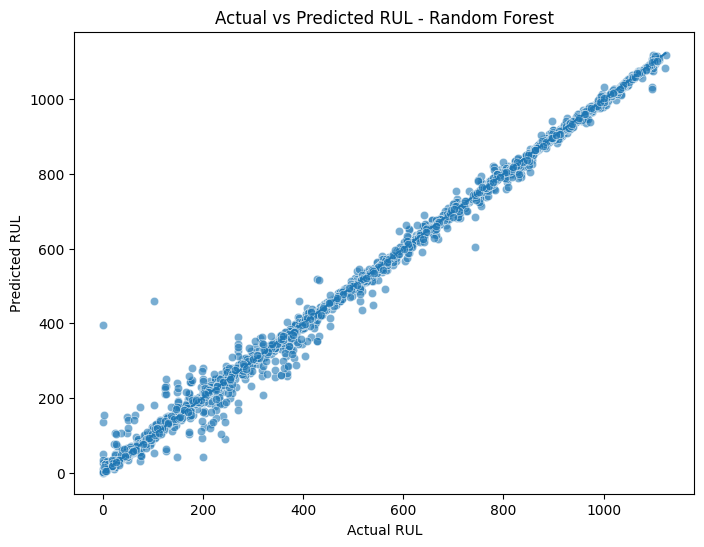

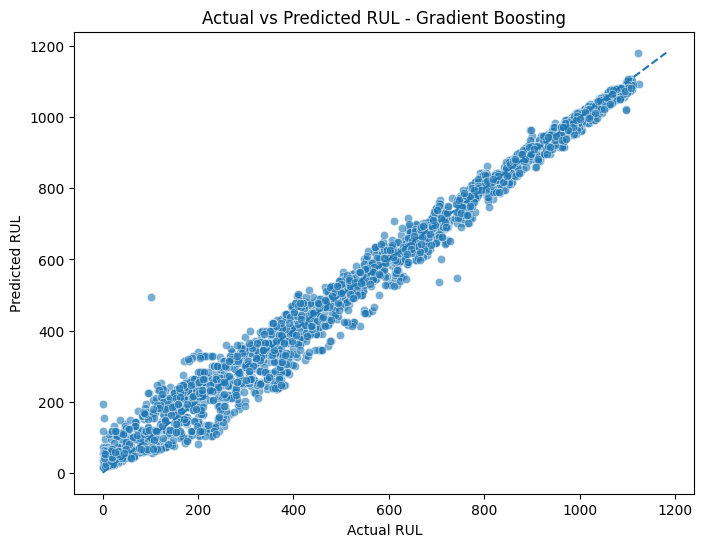

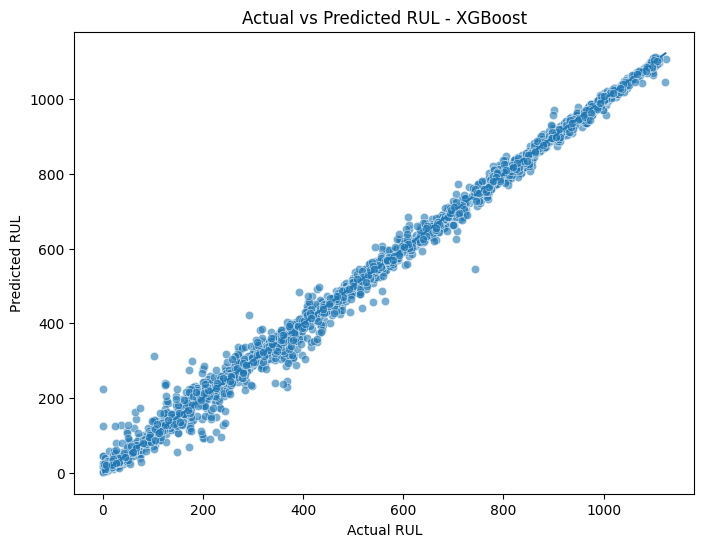

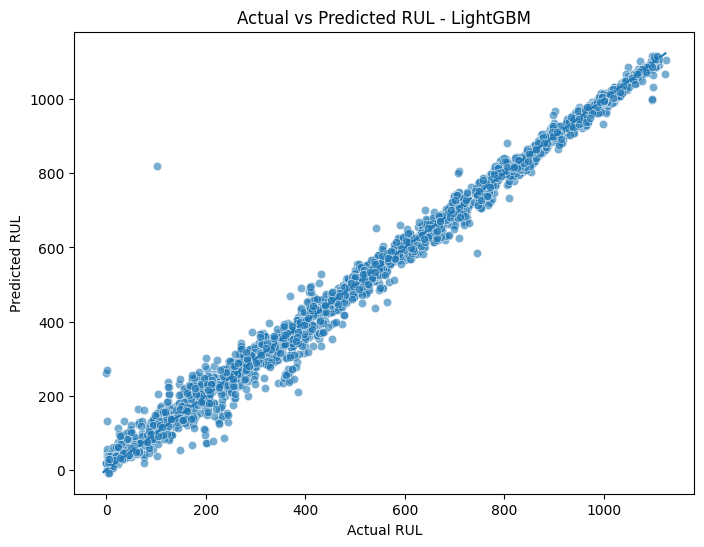

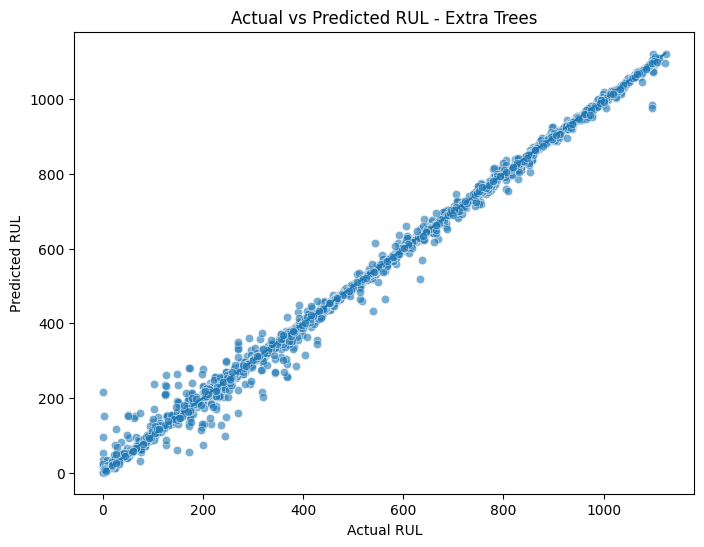

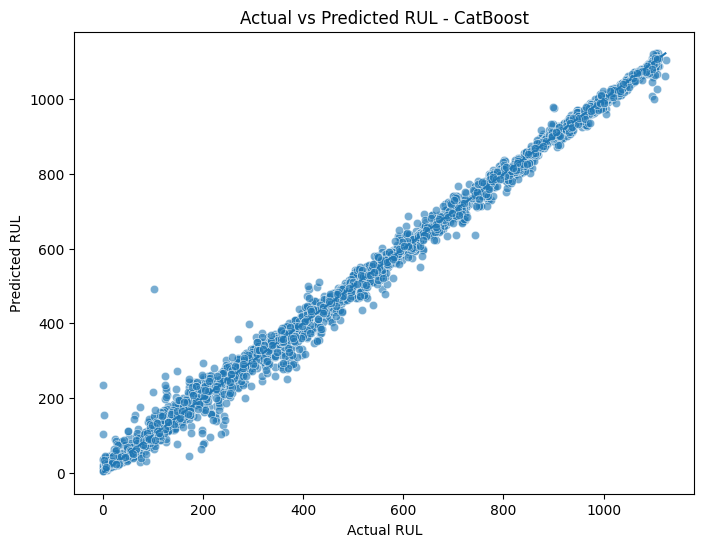

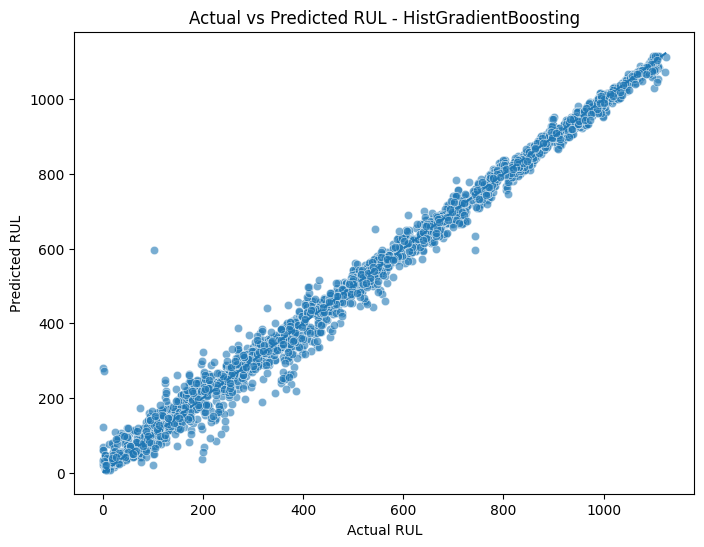

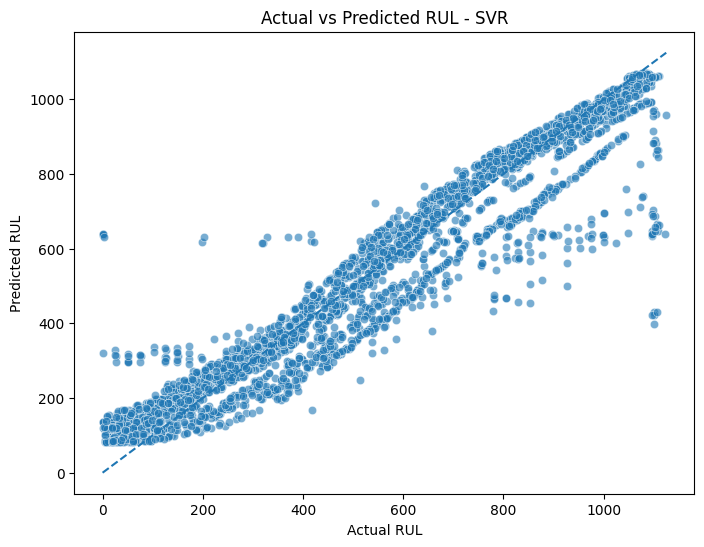

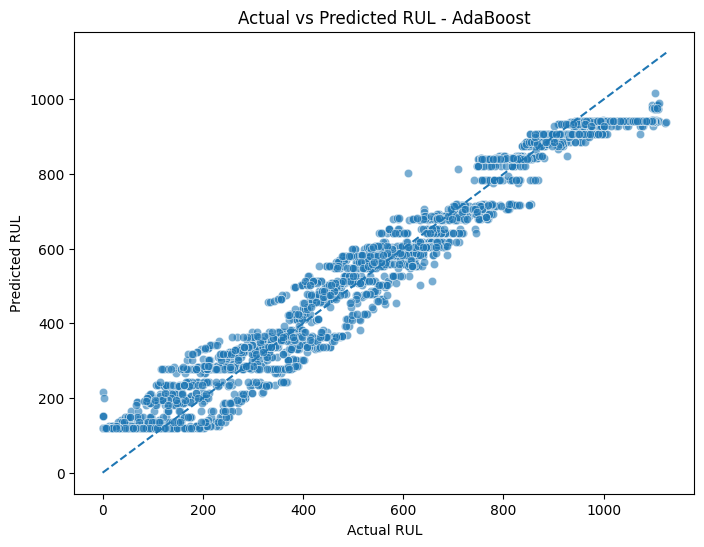

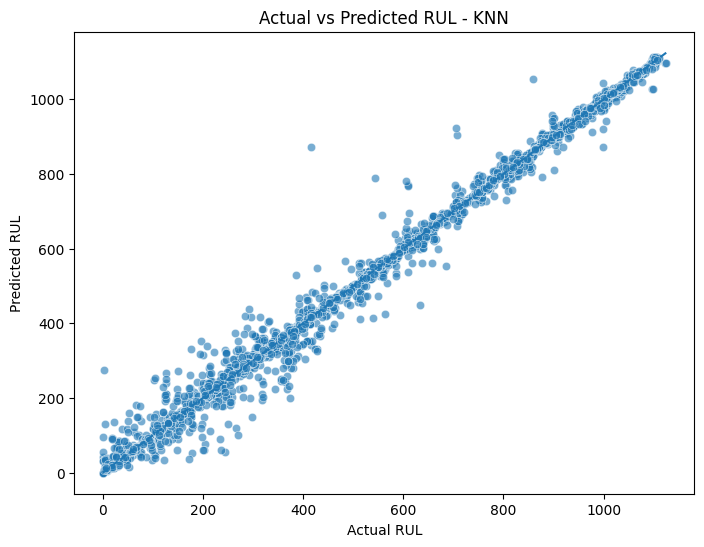

In [74]:
for name in models:

    predictions = test_predictions[name]

    plt.figure(figsize=(8, 6))

    sns.scatterplot(
        x=y_test,
        y=predictions,
        alpha=0.6
    )

    min_value = min(
        y_test.min(),
        predictions.min()
    )

    max_value = max(
        y_test.max(),
        predictions.max()
    )

    plt.plot(
        [min_value, max_value],
        [min_value, max_value],
        linestyle="--"
    )

    plt.title(
        "Actual vs Predicted RUL - " + name
    )

    plt.xlabel("Actual RUL")
    plt.ylabel("Predicted RUL")

    plt.show()